In [2]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/datasets/bhargavadepu/india-waterborne-disease-dataset/waterborne_disease_dataset.csv


In [3]:
import os

for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

/kaggle/input/datasets/bhargavadepu/india-waterborne-disease-dataset/waterborne_disease_dataset.csv


In [2]:
import pandas as pd

df = pd.read_csv(
    "/kaggle/input/datasets/bhargavadepu/india-waterborne-disease-dataset/waterborne_disease_dataset.csv"
)

df.head()

,state,district,region,latitude,longitude,is_urban,population_density,age,gender,water_source,...,flooding,symptom_diarrhea,symptom_vomiting,symptom_fever,symptom_abdominal_pain,symptom_dehydration,symptom_jaundice,symptom_bloody_stool,symptom_skin_rash,disease
0,Punjab,Hoshiarpur,North,29.8343,75.6466,1,402,22,Female,Open Well,...,1,0,0,0,0,0,0,0,0,No_Disease
1,Assam,Tinsukia,Northeast,25.7467,90.2411,0,505,22,Female,Borewell,...,0,1,0,1,1,1,0,1,0,Dysentery
2,Uttar Pradesh,Jhansi,North,24.9883,77.8044,0,727,43,Female,Borewell,...,1,0,0,0,0,0,0,0,0,No_Disease
3,Jammu and Kashmir,Kulgam,North,34.4923,76.0545,1,70,52,Male,Piped,...,1,0,0,0,0,0,0,0,0,No_Disease
4,Madhya Pradesh,Khargone,Central,24.5406,78.0276,0,308,23,Female,Pond,...,0,0,0,1,1,0,1,0,0,Typhoid


In [5]:
df.shape

(5250000, 41)

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5250000 entries, 0 to 5249999
Data columns (total 41 columns):
 #   Column                    Dtype  
---  ------                    -----  
 0   state                     object 
 1   district                  object 
 2   region                    object 
 3   latitude                  float64
 4   longitude                 float64
 5   is_urban                  int64  
 6   population_density        int64  
 7   age                       int64  
 8   gender                    object 
 9   water_source              object 
 10  water_treatment           object 
 11  water_quality_index       float64
 12  ph                        float64
 13  turbidity_ntu             float64
 14  dissolved_oxygen_mg_l     float64
 15  bod_mg_l                  float64
 16  fecal_coliform_per_100ml  int64  
 17  total_coliform_per_100ml  int64  
 18  tds_mg_l                  float64
 19  nitrate_mg_l              float64
 20  fluoride_mg_l           

In [7]:
df.describe()

,latitude,longitude,is_urban,population_density,age,water_quality_index,ph,turbidity_ntu,dissolved_oxygen_mg_l,bod_mg_l,...,avg_humidity_pct,flooding,symptom_diarrhea,symptom_vomiting,symptom_fever,symptom_abdominal_pain,symptom_dehydration,symptom_jaundice,symptom_bloody_stool,symptom_skin_rash
count,5.250000e+06,5.250000e+06,5.250000e+06,5.250000e+06,5.250000e+06,5.250000e+06,5.250000e+06,5.250000e+06,5.250000e+06,5.250000e+06,...,5.250000e+06,5.250000e+06,5.250000e+06,5.250000e+06,5.250000e+06,5.250000e+06,5.250000e+06,5.250000e+06,5.250000e+06,5.250000e+06
mean,2.321265e+01,8.094856e+01,4.302411e-01,7.320138e+02,2.692844e+01,4.809634e+01,7.341049e+00,1.708703e+01,7.111908e+00,1.082554e+01,...,6.349644e+01,1.527198e-01,3.752935e-01,2.831055e-01,4.166350e-01,4.568950e-01,2.739352e-01,1.530103e-01,1.190977e-01,6.714229e-02
std,6.233253e+00,6.392123e+00,4.951098e-01,1.361916e+03,1.845203e+01,2.775082e+01,5.498608e-01,1.309646e+01,3.231672e+00,8.096370e+00,...,1.882075e+01,3.597172e-01,4.841987e-01,4.505073e-01,4.930013e-01,4.981385e-01,4.459762e-01,3.599974e-01,3.239035e-01,2.502683e-01
min,6.500300e+00,6.800000e+01,0.000000e+00,3.000000e+00,0.000000e+00,1.000000e+01,6.000000e+00,0.000000e+00,2.000000e+00,0.000000e+00,...,2.000000e+01,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
25%,1.977800e+01,7.641360e+01,0.000000e+00,2.760000e+02,1.200000e+01,2.460000e+01,6.930000e+00,5.000000e+00,4.500000e+00,3.100000e+00,...,4.810000e+01,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
50%,2.433375e+01,7.928840e+01,0.000000e+00,4.530000e+02,2.500000e+01,3.530000e+01,7.330000e+00,1.540000e+01,6.300000e+00,1.050000e+01,...,6.240000e+01,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
75%,2.754360e+01,8.480980e+01,1.000000e+00,7.530000e+02,3.900000e+01,7.500000e+01,7.750000e+00,2.800000e+01,9.600000e+00,1.760000e+01,...,7.980000e+01,0.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
max,3.700000e+01,9.750000e+01,1.000000e+00,1.200000e+04,9.000000e+01,1.000000e+02,8.500000e+00,5.000000e+01,1.400000e+01,3.000000e+01,...,9.800000e+01,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00


In [8]:
df.isnull().sum()

state                       0
district                    0
region                      0
latitude                    0
longitude                   0
is_urban                    0
population_density          0
age                         0
gender                      0
water_source                0
water_treatment             0
water_quality_index         0
ph                          0
turbidity_ntu               0
dissolved_oxygen_mg_l       0
bod_mg_l                    0
fecal_coliform_per_100ml    0
total_coliform_per_100ml    0
tds_mg_l                    0
nitrate_mg_l                0
fluoride_mg_l               0
arsenic_ug_l                0
open_defecation_rate        0
toilet_access               0
sewage_treatment_pct        0
handwashing_practice        0
month                       0
season                      0
avg_temperature_c           0
avg_rainfall_mm             0
avg_humidity_pct            0
flooding                    0
symptom_diarrhea            0
symptom_vo

In [9]:
df.duplicated().sum()

np.int64(0)

In [10]:
df["disease"].value_counts()

disease
No_Disease       2101546
Typhoid           629079
Giardiasis        525509
Dysentery         524471
Cholera           419811
Hepatitis_A       419647
Hepatitis_E       367253
Leptospirosis     262684
Name: count, dtype: int64

In [11]:
df["disease"].value_counts()

disease
No_Disease       2101546
Typhoid           629079
Giardiasis        525509
Dysentery         524471
Cholera           419811
Hepatitis_A       419647
Hepatitis_E       367253
Leptospirosis     262684
Name: count, dtype: int64

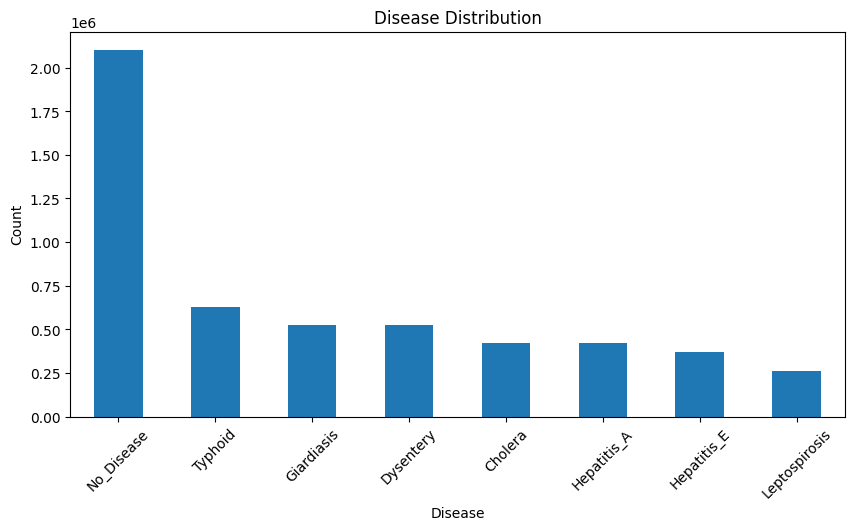

In [12]:
import matplotlib.pyplot as plt

df["disease"].value_counts().plot(
    kind="bar",
    figsize=(10,5)
)

plt.title("Disease Distribution")
plt.xlabel("Disease")
plt.ylabel("Count")
plt.xticks(rotation=45)

plt.show()

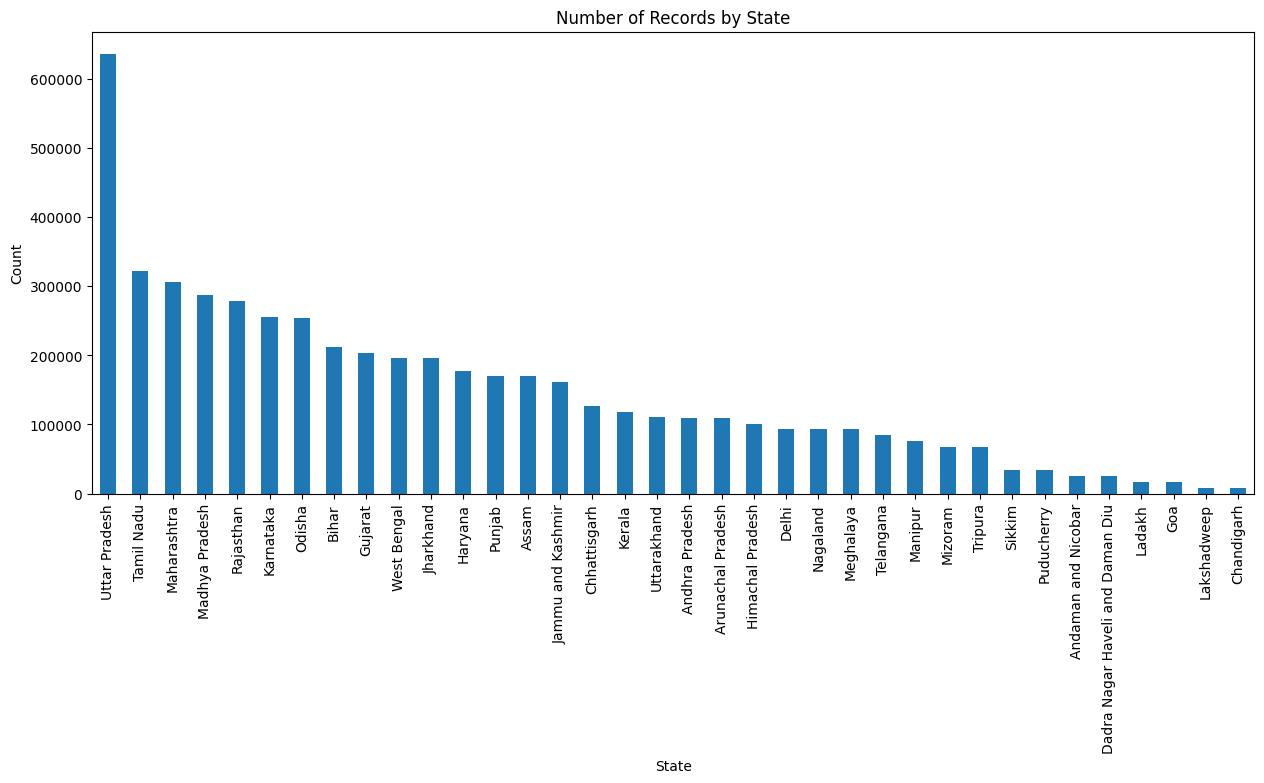

In [13]:
plt.figure(figsize=(15,6))

df["state"].value_counts().plot(kind="bar")

plt.title("Number of Records by State")
plt.xlabel("State")
plt.ylabel("Count")
plt.xticks(rotation=90)

plt.show()

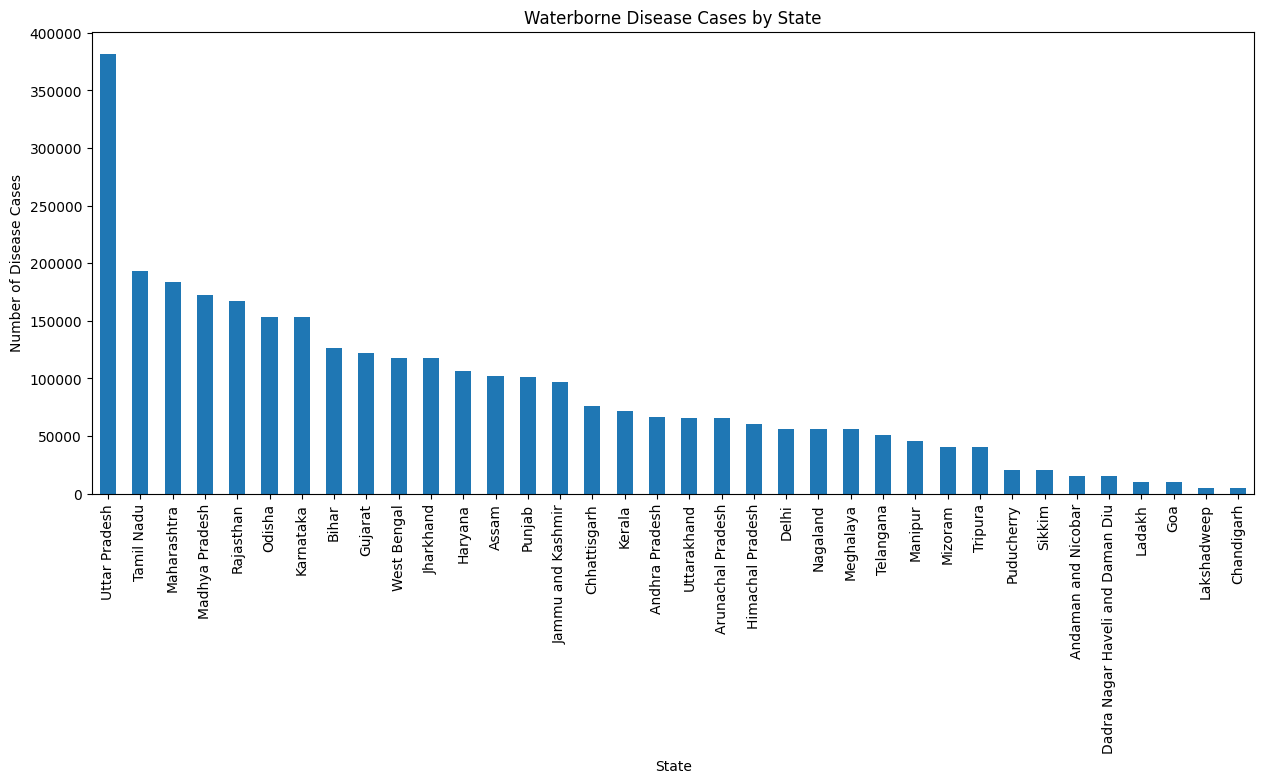

In [14]:
# Remove healthy individuals
disease_df = df[df["disease"] != "No_Disease"]

plt.figure(figsize=(15,6))

disease_df["state"].value_counts().plot(kind="bar")

plt.title("Waterborne Disease Cases by State")
plt.xlabel("State")
plt.ylabel("Number of Disease Cases")
plt.xticks(rotation=90)

plt.show()

In [15]:
# Keep only disease cases
disease_df = df[df["disease"] != "No_Disease"]

top_districts = disease_df["district"].value_counts().head(20)

print(top_districts)

district
Bilaspur           10193
Hamirpur           10172
Aurangabad         10094
Pratapgarh         10062
Vijayapura          5283
Chandauli           5267
South Andaman       5265
Lalitpur            5263
Ganderbal           5263
Uttar Dinajpur      5259
Jamtara             5256
Dimapur             5249
Meerut              5240
Azamgarh            5239
Erode               5239
Bikaner             5237
Dhamtari            5229
Mayurbhanj          5227
Purba Medinipur     5222
Katihar             5221
Name: count, dtype: int64


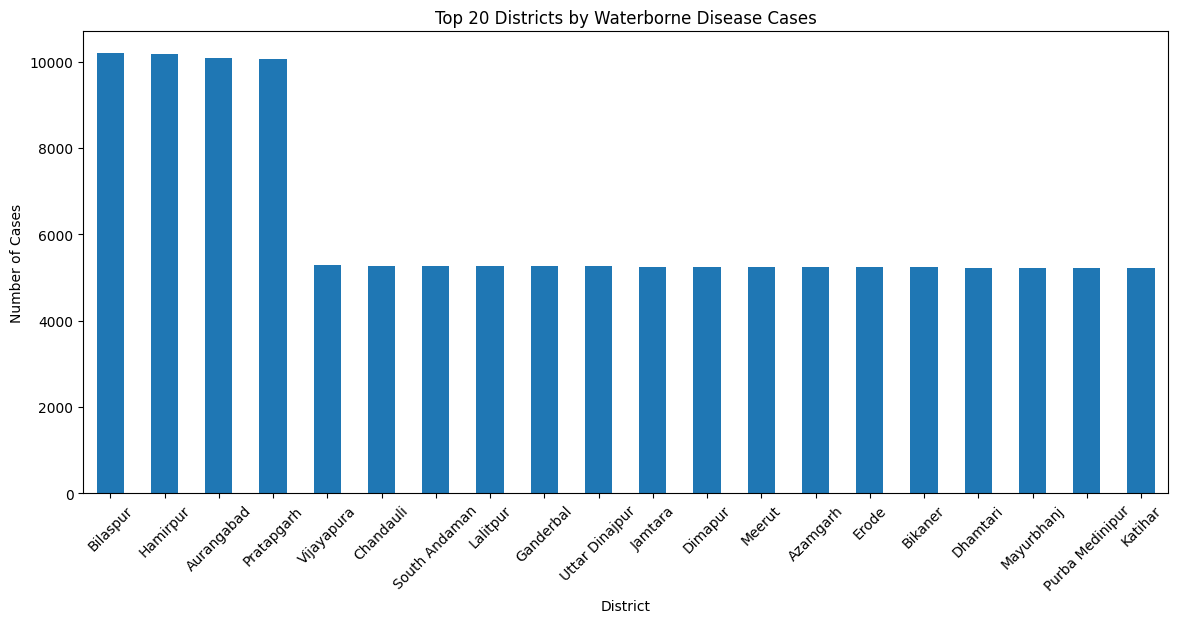

In [16]:
import matplotlib.pyplot as plt

plt.figure(figsize=(14,6))

top_districts.plot(kind="bar")

plt.title("Top 20 Districts by Waterborne Disease Cases")
plt.xlabel("District")
plt.ylabel("Number of Cases")
plt.xticks(rotation=45)

plt.show()

<Figure size 1200x600 with 0 Axes>

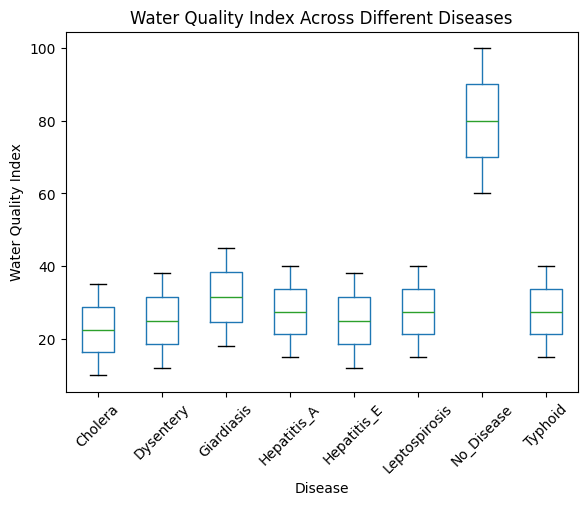

In [17]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,6))

df.boxplot(column="water_quality_index", by="disease", grid=False)

plt.title("Water Quality Index Across Different Diseases")
plt.suptitle("")  # Removes default title
plt.xlabel("Disease")
plt.ylabel("Water Quality Index")

plt.xticks(rotation=45)
plt.show()

<Figure size 1200x600 with 0 Axes>

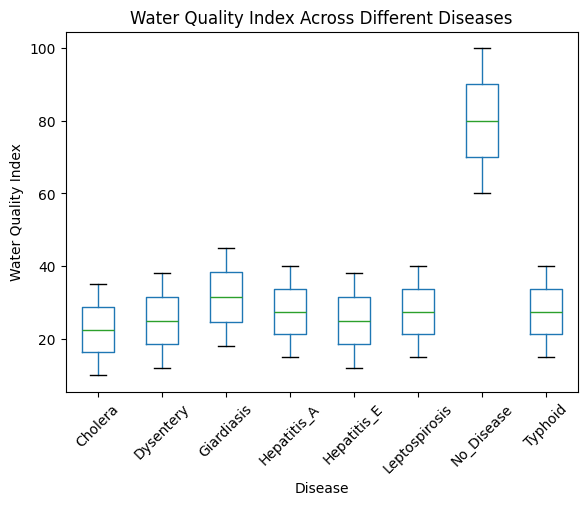

In [4]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,6))

df.boxplot(
    column="water_quality_index",
    by="disease",
    grid=False
)

plt.title("Water Quality Index Across Different Diseases")
plt.suptitle("")
plt.xlabel("Disease")
plt.ylabel("Water Quality Index")

plt.xticks(rotation=45)

plt.show()

In [5]:
df.groupby("disease")["water_quality_index"].mean().sort_values()

disease
Cholera          22.507551
Hepatitis_E      25.003366
Dysentery        25.009834
Leptospirosis    27.500803
Typhoid          27.506794
Hepatitis_A      27.510097
Giardiasis       31.505171
No_Disease       80.002344
Name: water_quality_index, dtype: float64

In [6]:
season_disease = pd.crosstab(df["season"], df["disease"])

season_disease

disease,Cholera,Dysentery,Giardiasis,Hepatitis_A,Hepatitis_E,Leptospirosis,No_Disease,Typhoid
season,,,,,,,,
Monsoon,230825,235824,183969,168030,183615,144349,525670,252229
Post-Monsoon,104687,104812,130888,104694,91609,91925,526970,125783
Summer,42262,105216,131530,83991,55316,13322,523622,157155
Winter,42037,78619,79122,62932,36713,13088,525284,93912


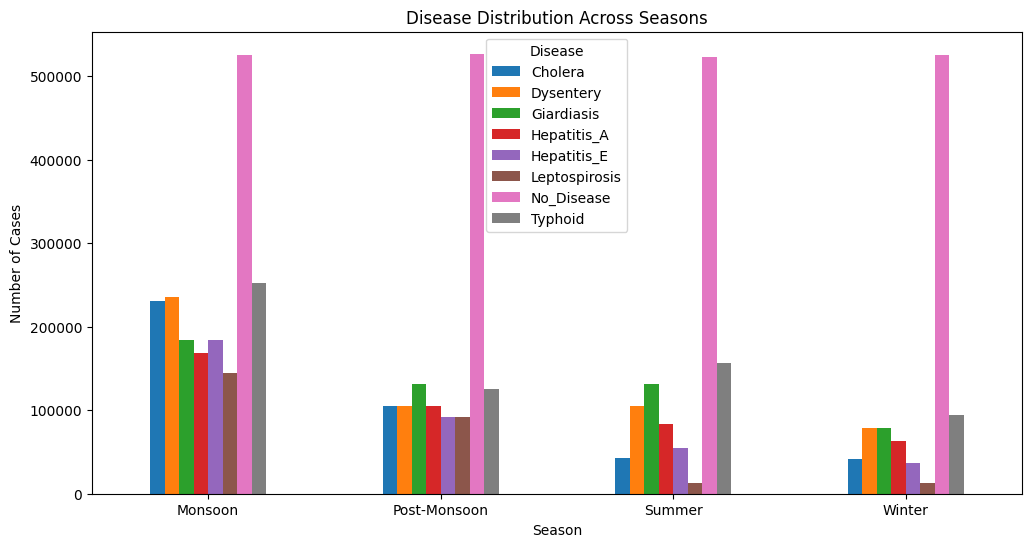

In [7]:
import matplotlib.pyplot as plt

season_disease.plot(
    kind="bar",
    figsize=(12,6)
)

plt.title("Disease Distribution Across Seasons")
plt.xlabel("Season")
plt.ylabel("Number of Cases")

plt.xticks(rotation=0)

plt.legend(title="Disease")

plt.show()

In [9]:
season_disease = pd.crosstab(df["season"], df["disease"])
season_disease

disease,Cholera,Dysentery,Giardiasis,Hepatitis_A,Hepatitis_E,Leptospirosis,No_Disease,Typhoid
season,,,,,,,,
Monsoon,230825,235824,183969,168030,183615,144349,525670,252229
Post-Monsoon,104687,104812,130888,104694,91609,91925,526970,125783
Summer,42262,105216,131530,83991,55316,13322,523622,157155
Winter,42037,78619,79122,62932,36713,13088,525284,93912


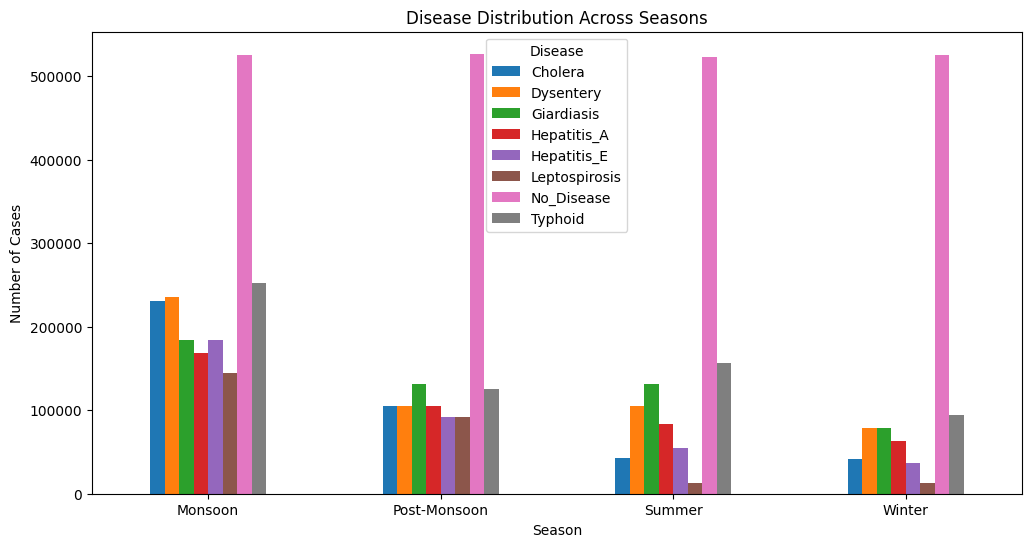

In [11]:
import matplotlib.pyplot as plt

season_disease.plot(
    kind="bar",
    figsize=(12,6)
)

plt.title("Disease Distribution Across Seasons")
plt.xlabel("Season")
plt.ylabel("Number of Cases")
plt.xticks(rotation=0)

plt.legend(title="Disease")

plt.show()

In [12]:
season_disease = pd.crosstab(df["season"], df["disease"])

season_disease

disease,Cholera,Dysentery,Giardiasis,Hepatitis_A,Hepatitis_E,Leptospirosis,No_Disease,Typhoid
season,,,,,,,,
Monsoon,230825,235824,183969,168030,183615,144349,525670,252229
Post-Monsoon,104687,104812,130888,104694,91609,91925,526970,125783
Summer,42262,105216,131530,83991,55316,13322,523622,157155
Winter,42037,78619,79122,62932,36713,13088,525284,93912


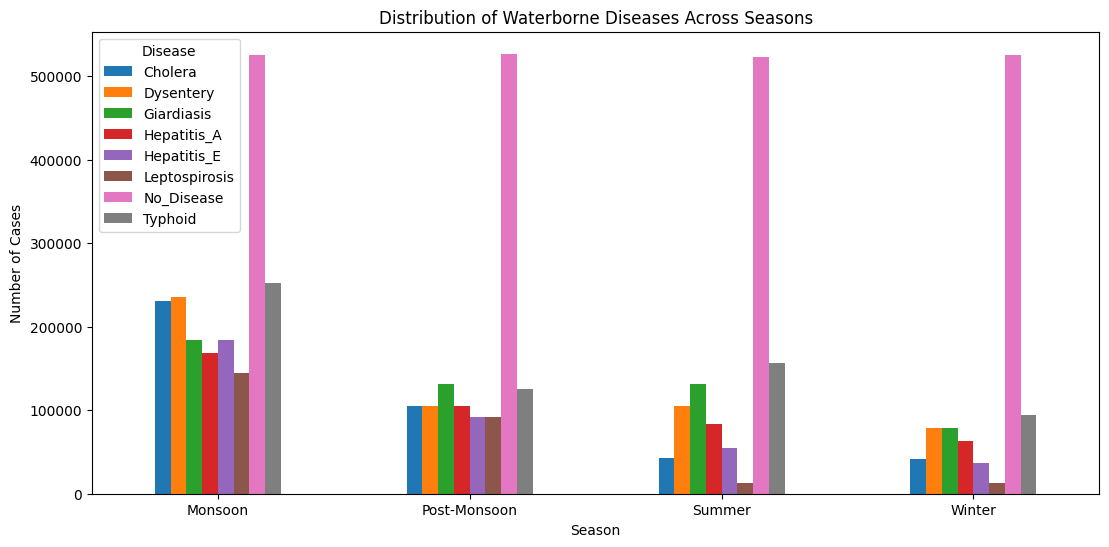

In [13]:
import matplotlib.pyplot as plt

season_disease.plot(
    kind="bar",
    figsize=(13,6)
)

plt.title("Distribution of Waterborne Diseases Across Seasons")
plt.xlabel("Season")
plt.ylabel("Number of Cases")

plt.xticks(rotation=0)

plt.legend(title="Disease")

plt.show()

In [16]:
pd.crosstab(
    df["flooding"],
    df["disease"],
    normalize="index"
) * 100

disease,Cholera,Dysentery,Giardiasis,Hepatitis_A,Hepatitis_E,Leptospirosis,No_Disease,Typhoid
flooding,,,,,,,,
0,7.554796,9.877027,10.038508,7.899473,6.713583,4.579921,41.328432,12.008261
1,10.446395,10.616267,9.849846,8.513693,8.558219,7.353523,32.822760,11.839297


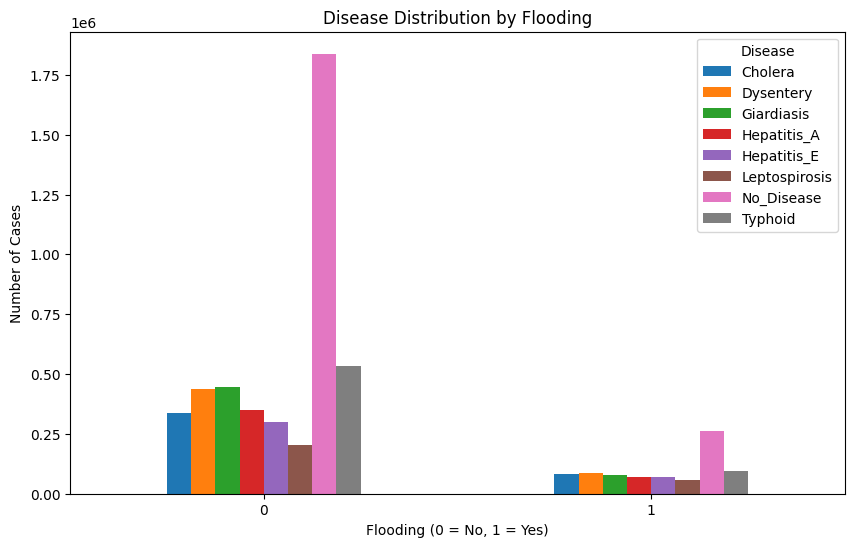

In [15]:
import matplotlib.pyplot as plt

flood_disease.plot(
    kind="bar",
    figsize=(10,6)
)

plt.title("Disease Distribution by Flooding")
plt.xlabel("Flooding (0 = No, 1 = Yes)")
plt.ylabel("Number of Cases")

plt.xticks(rotation=0)

plt.legend(title="Disease")

plt.show()

In [17]:
flood_percentage = pd.crosstab(
    df["flooding"],
    df["disease"],
    normalize="index"
) * 100

print(flood_percentage.round(2))

disease   Cholera  Dysentery  Giardiasis  Hepatitis_A  Hepatitis_E  \
flooding                                                             
0            7.55       9.88       10.04         7.90         6.71   
1           10.45      10.62        9.85         8.51         8.56   

disease   Leptospirosis  No_Disease  Typhoid  
flooding                                      
0                  4.58       41.33    12.01  
1                  7.35       32.82    11.84  


In [19]:
water_disease = pd.crosstab(df["water_source"], df["disease"])

water_disease

disease,Cholera,Dysentery,Giardiasis,Hepatitis_A,Hepatitis_E,Leptospirosis,No_Disease,Typhoid
water_source,,,,,,,,
Borewell,41663,62926,78838,62621,44020,26081,525156,94622
Open Well,62788,116228,131425,84339,73188,39396,210115,126227
Piped,20865,41698,52370,41572,29587,13248,840862,63043
Pond,84474,94531,131932,83822,73713,65522,105296,94177
Rainwater,21046,26236,26167,21091,18161,26300,147117,31500
River,147065,130841,78556,84435,91744,78915,167702,156602
Tanker,41910,52011,26221,41767,36840,13222,105298,62908


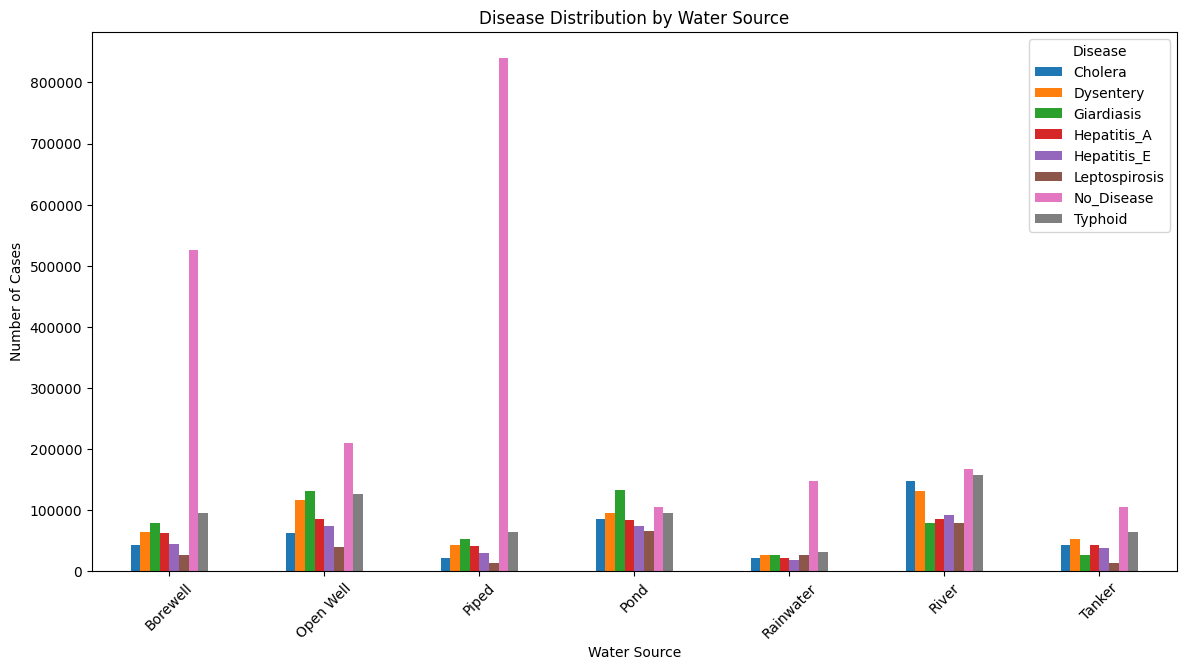

In [20]:
import matplotlib.pyplot as plt

water_disease.plot(
    kind="bar",
    figsize=(14,7)
)

plt.title("Disease Distribution by Water Source")
plt.xlabel("Water Source")
plt.ylabel("Number of Cases")

plt.xticks(rotation=45)

plt.legend(title="Disease")

plt.show()

In [21]:
water_percentage = pd.crosstab(
    df["water_source"],
    df["disease"],
    normalize="index"
) * 100

water_percentage.round(2)

disease,Cholera,Dysentery,Giardiasis,Hepatitis_A,Hepatitis_E,Leptospirosis,No_Disease,Typhoid
water_source,,,,,,,,
Borewell,4.45,6.72,8.42,6.69,4.70,2.79,56.11,10.11
Open Well,7.44,13.78,15.58,10.00,8.67,4.67,24.90,14.96
Piped,1.89,3.78,4.75,3.77,2.68,1.20,76.22,5.71
Pond,11.52,12.89,17.99,11.43,10.05,8.93,14.36,12.84
Rainwater,6.63,8.26,8.24,6.64,5.72,8.28,46.32,9.92
River,15.71,13.98,8.39,9.02,9.80,8.43,17.92,16.73
Tanker,11.02,13.68,6.90,10.99,9.69,3.48,27.70,16.55


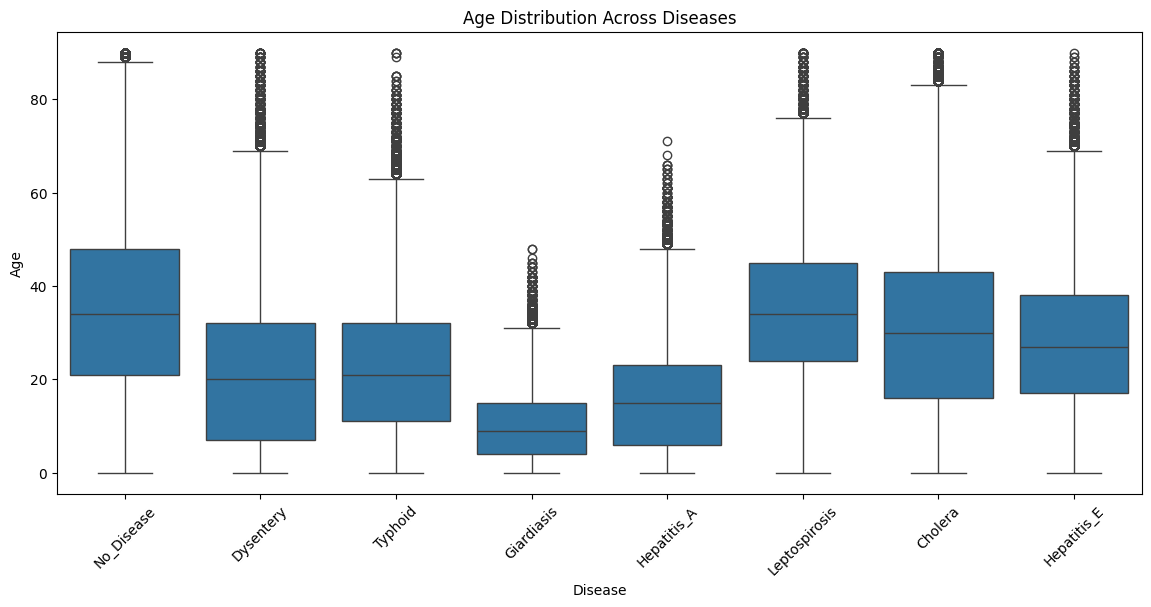

In [3]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(14,6))

sns.boxplot(
    x="disease",
    y="age",
    data=df
)

plt.title("Age Distribution Across Diseases")
plt.xlabel("Disease")
plt.ylabel("Age")

plt.xticks(rotation=45)

plt.show()

In [4]:
df.groupby("disease")["age"].mean().sort_values()

disease
Giardiasis        9.957767
Hepatitis_A      15.161190
Dysentery        20.777460
Typhoid          22.011259
Hepatitis_E      27.679319
Cholera          30.147421
Leptospirosis    34.543215
No_Disease       34.802761
Name: age, dtype: float64

In [2]:
gender_disease = pd.crosstab(df["gender"], df["disease"])

gender_disease

disease,Cholera,Dysentery,Giardiasis,Hepatitis_A,Hepatitis_E,Leptospirosis,No_Disease,Typhoid
gender,,,,,,,,
Female,209800,262650,262976,209975,183642,131748,1051090,314481
Male,210011,261821,262533,209672,183611,130936,1050456,314598


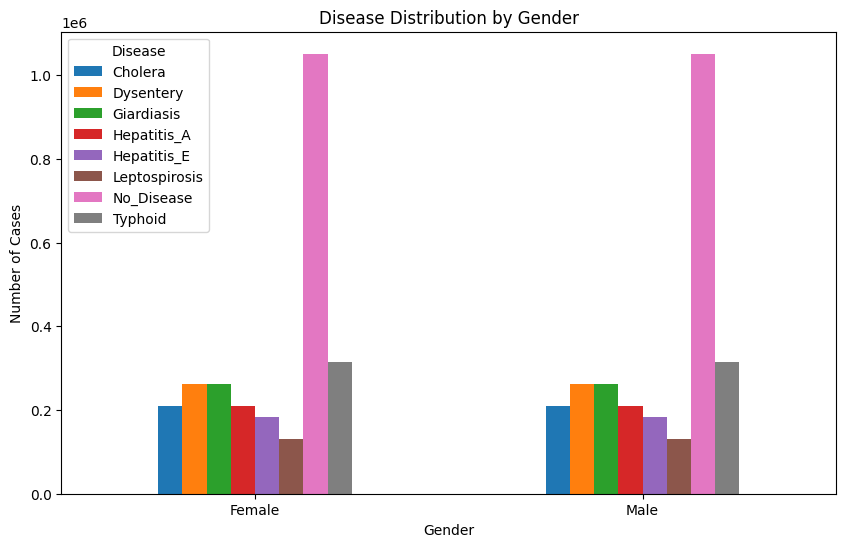

In [3]:
import matplotlib.pyplot as plt

gender_disease.plot(
    kind="bar",
    figsize=(10,6)
)

plt.title("Disease Distribution by Gender")
plt.xlabel("Gender")
plt.ylabel("Number of Cases")

plt.xticks(rotation=0)
plt.legend(title="Disease")

plt.show()

In [4]:
gender_percentage = pd.crosstab(
    df["gender"],
    df["disease"],
    normalize="index"
) * 100

gender_percentage.round(2)

disease,Cholera,Dysentery,Giardiasis,Hepatitis_A,Hepatitis_E,Leptospirosis,No_Disease,Typhoid
gender,,,,,,,,
Female,7.99,10.00,10.01,7.99,6.99,5.02,40.02,11.97
Male,8.00,9.98,10.01,7.99,7.00,4.99,40.04,11.99


In [3]:
urban_disease = pd.crosstab(df["is_urban"], df["disease"])

urban_disease

disease,Cholera,Dysentery,Giardiasis,Hepatitis_A,Hepatitis_E,Leptospirosis,No_Disease,Typhoid
is_urban,,,,,,,,
0,315117,367005,341003,251641,257061,209829,840834,408744
1,104694,157466,184506,168006,110192,52855,1260712,220335


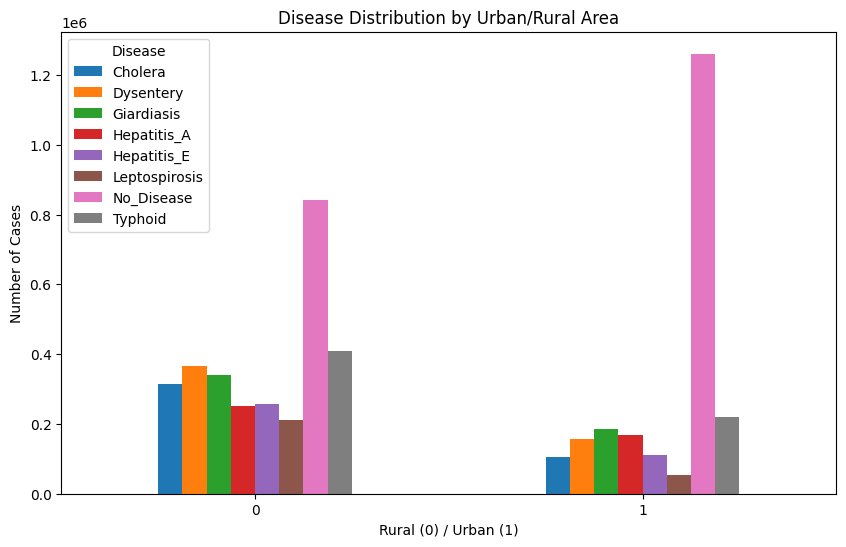

In [4]:
import matplotlib.pyplot as plt

urban_disease.plot(
    kind="bar",
    figsize=(10,6)
)

plt.title("Disease Distribution by Urban/Rural Area")
plt.xlabel("Rural (0) / Urban (1)")
plt.ylabel("Number of Cases")
plt.xticks(rotation=0)
plt.legend(title="Disease")

plt.show()

In [5]:
urban_percentage = pd.crosstab(
    df["is_urban"],
    df["disease"],
    normalize="index"
) * 100

urban_percentage.round(2)

disease,Cholera,Dysentery,Giardiasis,Hepatitis_A,Hepatitis_E,Leptospirosis,No_Disease,Typhoid
is_urban,,,,,,,,
0,10.53,12.27,11.40,8.41,8.59,7.01,28.11,13.66
1,4.64,6.97,8.17,7.44,4.88,2.34,55.81,9.75


In [6]:
handwash_disease = pd.crosstab(
    df["handwashing_practice"],
    df["disease"]
)

handwash_disease

disease,Cholera,Dysentery,Giardiasis,Hepatitis_A,Hepatitis_E,Leptospirosis,No_Disease,Typhoid
handwashing_practice,,,,,,,,
Always,20738,26238,52738,41822,29526,20932,1261641,62857
Never,293889,366794,315488,231188,227457,162946,209753,377526
Sometimes,105184,131439,157283,146637,110270,78806,630152,188696


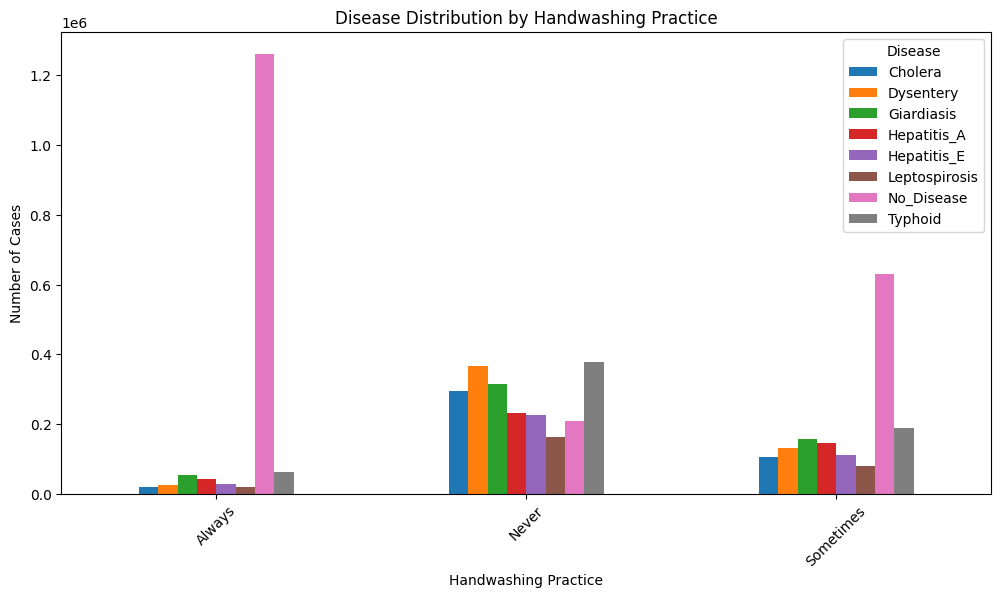

In [7]:
import matplotlib.pyplot as plt

handwash_disease.plot(
    kind="bar",
    figsize=(12,6)
)

plt.title("Disease Distribution by Handwashing Practice")
plt.xlabel("Handwashing Practice")
plt.ylabel("Number of Cases")
plt.xticks(rotation=45)
plt.legend(title="Disease")

plt.show()

In [8]:
handwash_percentage = pd.crosstab(
    df["handwashing_practice"],
    df["disease"],
    normalize="index"
) * 100

handwash_percentage.round(2)

disease,Cholera,Dysentery,Giardiasis,Hepatitis_A,Hepatitis_E,Leptospirosis,No_Disease,Typhoid
handwashing_practice,,,,,,,,
Always,1.37,1.73,3.48,2.76,1.95,1.38,83.19,4.14
Never,13.45,16.79,14.44,10.58,10.41,7.46,9.60,17.28
Sometimes,6.79,8.49,10.16,9.47,7.12,5.09,40.70,12.19


In [9]:
treatment_disease = pd.crosstab(
    df["water_treatment"],
    df["disease"]
)

treatment_disease

disease,Cholera,Dysentery,Giardiasis,Hepatitis_A,Hepatitis_E,Leptospirosis,No_Disease,Typhoid
water_treatment,,,,,,,,
Boiled,20976,31413,42029,29519,21995,20713,526630,43757
Chlorinated,20959,31598,42148,33543,21820,26043,838553,50210
Filtered,42100,68302,73739,62689,47856,31707,526250,94612
Untreated,335776,393158,367593,293896,275582,184221,210113,440500


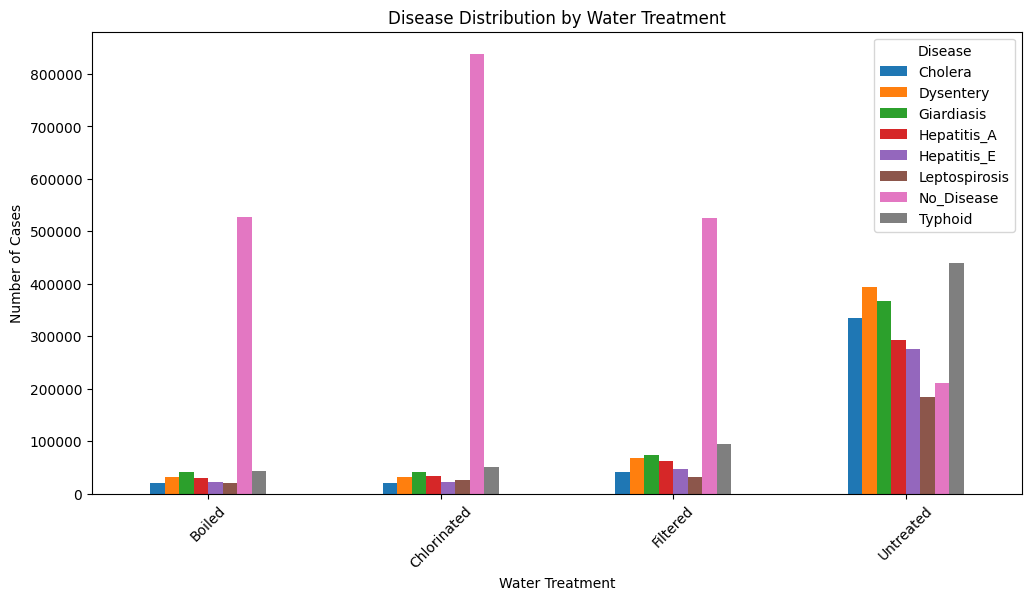

In [10]:
import matplotlib.pyplot as plt

treatment_disease.plot(
    kind="bar",
    figsize=(12,6)
)

plt.title("Disease Distribution by Water Treatment")
plt.xlabel("Water Treatment")
plt.ylabel("Number of Cases")

plt.xticks(rotation=45)

plt.legend(title="Disease")

plt.show()

In [11]:
treatment_percentage = pd.crosstab(
    df["water_treatment"],
    df["disease"],
    normalize="index"
) * 100

treatment_percentage.round(2)

disease,Cholera,Dysentery,Giardiasis,Hepatitis_A,Hepatitis_E,Leptospirosis,No_Disease,Typhoid
water_treatment,,,,,,,,
Boiled,2.85,4.26,5.70,4.01,2.98,2.81,71.45,5.94
Chlorinated,1.97,2.97,3.96,3.15,2.05,2.45,78.75,4.72
Filtered,4.44,7.21,7.78,6.62,5.05,3.35,55.56,9.99
Untreated,13.43,15.72,14.70,11.75,11.02,7.37,8.40,17.61


In [13]:
df_sample = df.sample(n=5000, random_state=42)

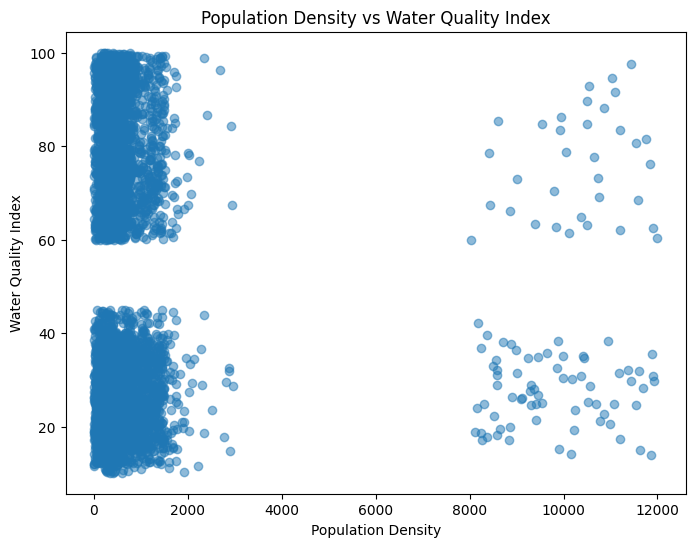

In [14]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))

plt.scatter(
    df_sample["population_density"],
    df_sample["water_quality_index"],
    alpha=0.5
)

plt.title("Population Density vs Water Quality Index")
plt.xlabel("Population Density")
plt.ylabel("Water Quality Index")

plt.show()

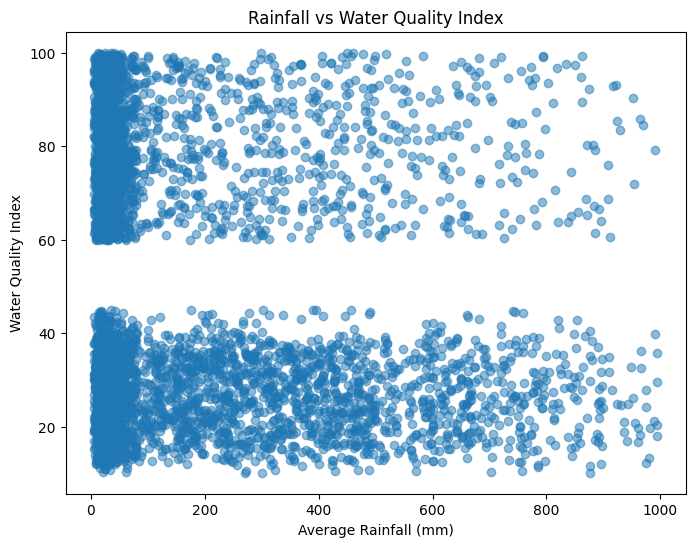

In [15]:
plt.figure(figsize=(8,6))

plt.scatter(
    df_sample["avg_rainfall_mm"],
    df_sample["water_quality_index"],
    alpha=0.5
)

plt.title("Rainfall vs Water Quality Index")
plt.xlabel("Average Rainfall (mm)")
plt.ylabel("Water Quality Index")

plt.show()

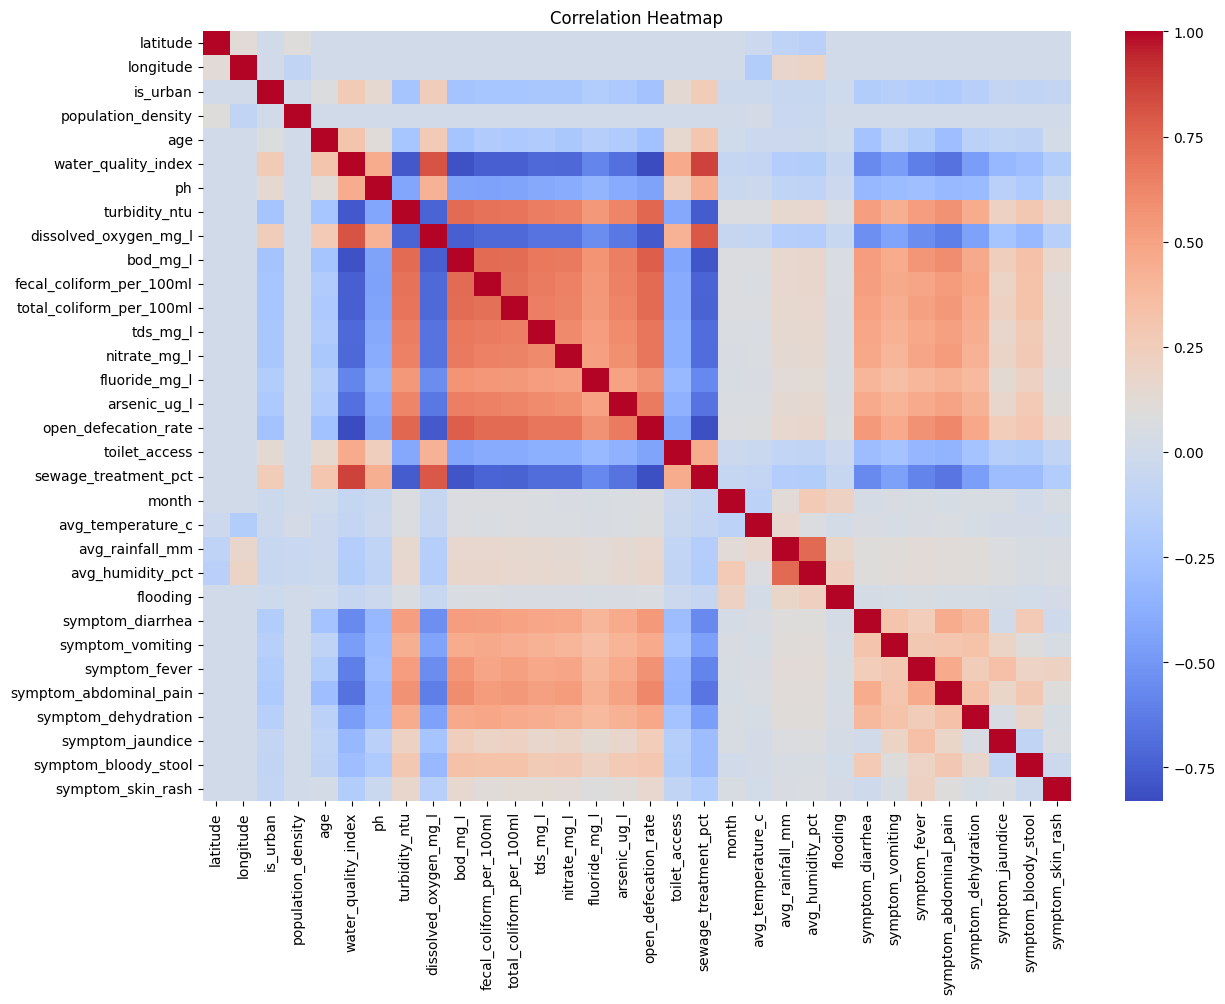

In [16]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(14,10))

numerical_df = df.select_dtypes(include=["int64","float64"])

corr = numerical_df.corr()

sns.heatmap(
    corr,
    cmap="coolwarm",
    annot=False
)

plt.title("Correlation Heatmap")

plt.show()

In [17]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

categorical_cols = df.select_dtypes(include="object").columns

for col in categorical_cols:
    df[col] = le.fit_transform(df[col])

df.head()

,state,district,region,latitude,longitude,is_urban,population_density,age,gender,water_source,...,flooding,symptom_diarrhea,symptom_vomiting,symptom_fever,symptom_abdominal_pain,symptom_dehydration,symptom_jaundice,symptom_bloody_stool,symptom_skin_rash,disease
0,27,213,2,29.8343,75.6466,1,402,22,0,1,...,1,0,0,0,0,0,0,0,0,6
1,3,558,3,25.7467,90.2411,0,505,22,0,0,...,0,1,0,1,1,1,0,1,0,1
2,33,241,2,24.9883,77.8044,0,727,43,0,0,...,1,0,0,0,0,0,0,0,0,6
3,13,308,2,34.4923,76.0545,1,70,52,1,2,...,1,0,0,0,0,0,0,0,0,6
4,19,284,0,24.5406,78.0276,0,308,23,0,3,...,0,0,0,1,1,0,1,0,0,7


In [5]:
X = df.drop("disease", axis=1)
y = df["disease"]

print("Features Shape:", X.shape)
print("Target Shape:", y.shape)

Features Shape: (5250000, 40)
Target Shape: (5250000,)


In [6]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print(X_train.shape)
print(X_test.shape)

(4200000, 40)
(1050000, 40)


In [12]:
print(df.dtypes)

state                        object
district                     object
region                       object
latitude                    float64
longitude                   float64
is_urban                      int64
population_density            int64
age                           int64
gender                       object
water_source                 object
water_treatment              object
water_quality_index         float64
ph                          float64
turbidity_ntu               float64
dissolved_oxygen_mg_l       float64
bod_mg_l                    float64
fecal_coliform_per_100ml      int64
total_coliform_per_100ml      int64
tds_mg_l                    float64
nitrate_mg_l                float64
fluoride_mg_l               float64
arsenic_ug_l                float64
open_defecation_rate        float64
toilet_access                 int64
sewage_treatment_pct        float64
handwashing_practice         object
month                         int64
season                      

In [13]:
print(X_train.head())

                 state        district region  latitude  longitude  is_urban  \
3527282  Uttar Pradesh         Kasganj  North   24.3565    82.0550         1   
4747895         Kerala        Thrissur  South    8.6775    77.0095         1   
4934455     Tamil Nadu  Mayiladuthurai  South    8.7542    79.5761         1   
4463659        Gujarat   Surendranagar   West   22.7183    73.5305         0   
4178084        Haryana          Ambala  North   29.0299    77.0282         0   

         population_density  age  gender water_source  ... avg_humidity_pct  \
3527282                 811   44  Female        Piped  ...             50.5   
4747895                 840   42  Female        River  ...             81.5   
4934455                 664   31  Female    Rainwater  ...             70.7   
4463659                 496   52    Male        River  ...             94.2   
4178084                 785   13    Male    Open Well  ...             63.7   

         flooding  symptom_diarrhea  symptom

In [14]:
from sklearn.preprocessing import LabelEncoder

# Make a copy so your original dataframe stays safe
df_encoded = df.copy()

# Encode all object columns
le = LabelEncoder()

for col in df_encoded.select_dtypes(include="object").columns:
    df_encoded[col] = le.fit_transform(df_encoded[col].astype(str))

print(df_encoded.dtypes)

state                         int64
district                      int64
region                        int64
latitude                    float64
longitude                   float64
is_urban                      int64
population_density            int64
age                           int64
gender                        int64
water_source                  int64
water_treatment               int64
water_quality_index         float64
ph                          float64
turbidity_ntu               float64
dissolved_oxygen_mg_l       float64
bod_mg_l                    float64
fecal_coliform_per_100ml      int64
total_coliform_per_100ml      int64
tds_mg_l                    float64
nitrate_mg_l                float64
fluoride_mg_l               float64
arsenic_ug_l                float64
open_defecation_rate        float64
toilet_access                 int64
sewage_treatment_pct        float64
handwashing_practice          int64
month                         int64
season                      

In [16]:
X = df_encoded.drop("disease", axis=1)
y = df_encoded["disease"]

In [17]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [19]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [20]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Scaling Completed!")

Scaling Completed!


In [25]:
df_ml = df_encoded.sample(
    n=300000,
    random_state=42
)

print(df_ml.shape)

(300000, 41)


In [28]:
X = df_ml.drop("disease", axis=1)
y = df_ml["disease"]

In [29]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [30]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(
    n_estimators=100,
    random_state=42,
    n_jobs=-1
)

rf.fit(X_train, y_train)

RandomForestClassifier(n_jobs=-1, random_state=42)

In [32]:
y_pred = rf.predict(X_test)

In [33]:
y_pred = rf.predict(X_test)

In [34]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

accuracy = accuracy_score(y_test, y_pred)

precision = precision_score(
    y_test,
    y_pred,
    average="weighted"
)

recall = recall_score(
    y_test,
    y_pred,
    average="weighted"
)

f1 = f1_score(
    y_test,
    y_pred,
    average="weighted"
)

print("Accuracy :", accuracy)
print("Precision:", precision)
print("Recall   :", recall)
print("F1 Score :", f1)

Accuracy : 0.9433833333333334
Precision: 0.9434466060823813
Recall   : 0.9433833333333334
F1 Score : 0.9430166391863063


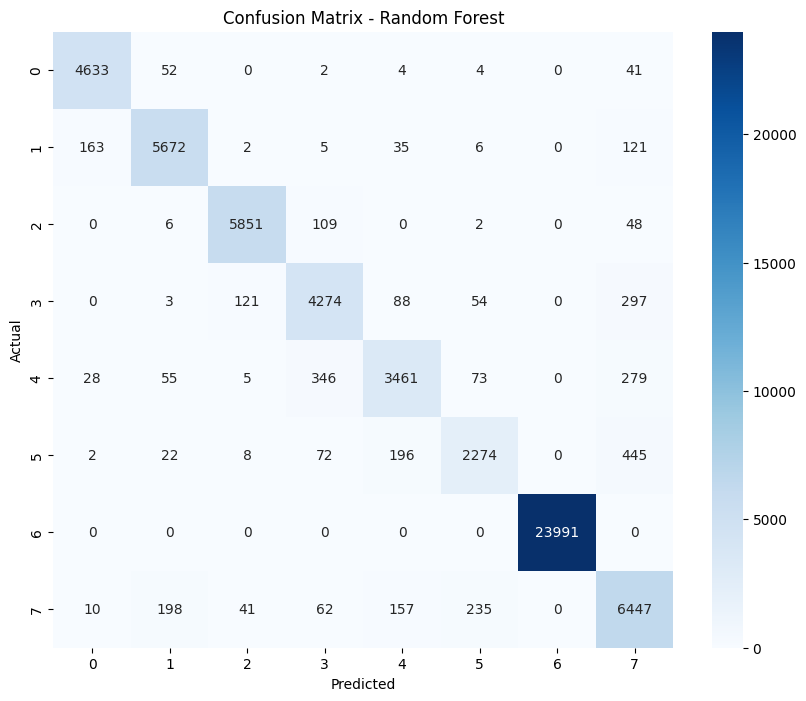

In [35]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(10,8))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues"
)

plt.title("Confusion Matrix - Random Forest")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

In [36]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(
    n_estimators=100,
    random_state=42,
    n_jobs=-1
)

rf.fit(X_train, y_train)

print("Random Forest Model Trained Successfully!")

Random Forest Model Trained Successfully!


In [38]:
y_pred = rf.predict(X_test)

In [39]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)

accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred, average="weighted")
recall = recall_score(y_test, y_pred, average="weighted")
f1 = f1_score(y_test, y_pred, average="weighted")

print("Accuracy :", round(accuracy,4))
print("Precision:", round(precision,4))
print("Recall   :", round(recall,4))
print("F1 Score :", round(f1,4))

Accuracy : 0.9434
Precision: 0.9434
Recall   : 0.9434
F1 Score : 0.943


In [40]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.96      0.98      0.97      4736
           1       0.94      0.94      0.94      6004
           2       0.97      0.97      0.97      6016
           3       0.88      0.88      0.88      4837
           4       0.88      0.81      0.85      4247
           5       0.86      0.75      0.80      3019
           6       1.00      1.00      1.00     23991
           7       0.84      0.90      0.87      7150

    accuracy                           0.94     60000
   macro avg       0.92      0.91      0.91     60000
weighted avg       0.94      0.94      0.94     60000



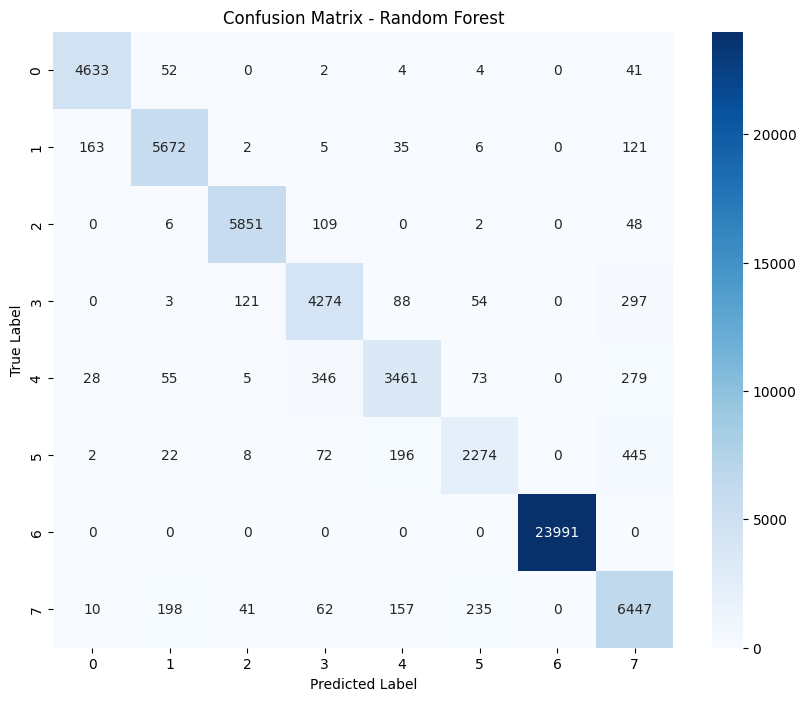

In [41]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(10,8))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues"
)

plt.title("Confusion Matrix - Random Forest")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")

plt.show()

In [42]:
import pandas as pd

importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": rf.feature_importances_
})

importance = importance.sort_values(
    by="Importance",
    ascending=False
)

importance.head(10)

,Feature,Importance
16,fecal_coliform_per_100ml,0.098280
17,total_coliform_per_100ml,0.095477
11,water_quality_index,0.081276
38,symptom_bloody_stool,0.067265
24,sewage_treatment_pct,0.065613
37,symptom_jaundice,0.064478
22,open_defecation_rate,0.052368
13,turbidity_ntu,0.047988
15,bod_mg_l,0.045467
18,tds_mg_l,0.043499


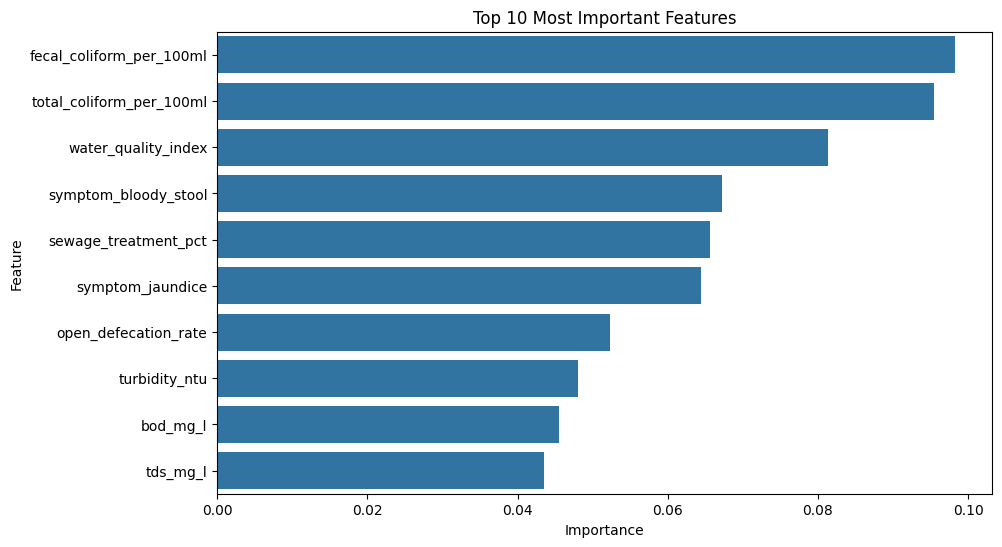

In [43]:
plt.figure(figsize=(10,6))

sns.barplot(
    data=importance.head(10),
    x="Importance",
    y="Feature"
)

plt.title("Top 10 Most Important Features")

plt.show()